# Data Loading and Cleaning

## Titanic Survival Dataset

This lab focuses on loading, inspecting, cleaning, and preparing the Titanic dataset for machine learning tasks.

The dataset contains information about Titanic passengers such as:
- age
- gender
- passenger class
- fare
- cabin
- embarked port

The objective is to predict whether a passenger survived or not.

Step 1: Import Libraries

In [26]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

Step 2: Load Dataset

In [28]:
df = pd.read_csv("train.csv")
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


## Dataset Overview

The Titanic dataset contains information about passengers aboard the RMS Titanic.

The target variable is:
- Survived
  - 1 = survived
  - 0 = not survived

This is a classification problem because the output contains categories.

Step 3: Inspect Shape and Data Types

In [29]:
print("Dataset Shape:", df.shape)
df.info()

Dataset Shape: (891, 12)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


## Initial Inspection

- `df.shape` shows the number of rows and columns.
- `df.info()` helps identify:
  - missing values
  - data types
  - non-null counts

This helps understand the structure of the dataset before cleaning.

Step 4: Summary Statistics

In [30]:
df.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


## Summary Statistics

Summary statistics provide:
- mean
- standard deviation
- minimum and maximum values
- quartiles

These statistics help identify outliers and understand numerical features.

Step 5: Check Missing Values

In [31]:
missing_values = df.isnull().sum()
print(missing_values)

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64


## Missing Values

The dataset contains missing values mainly in:
- Age
- Cabin
- Embarked

Missing values must be handled before machine learning.

Step 6: Handle Missing Age Values

In [33]:
df['Age'].fillna(df['Age'].median(), inplace=True)

C:\Users\HP\AppData\Local\Temp\ipykernel_6540\1933487976.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Age'].fillna(df['Age'].median(), inplace=True)


Step 7: Handle Missing Embarked Values

In [35]:
df['Embarked'].fillna(df['Embarked'].mode()[0], inplace=True)

C:\Users\HP\AppData\Local\Temp\ipykernel_6540\3744086084.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Embarked'].fillna(df['Embarked'].mode()[0], inplace=True)


Step 8: Drop Cabin Column

In [36]:
df.drop(columns=['Cabin'], inplace=True)

## Handling Missing Values

- Missing Age values were replaced using the median.
- Missing Embarked values were replaced using the mode.
- Cabin column was dropped because it contains too many missing values.

Median is more robust to outliers compared to mean.

Step 9: Check Missing Values Again

In [37]:
print(df.isnull().sum())

PassengerId    0
Survived       0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Embarked       0
dtype: int64


Step 10: Check Duplicate Rows

In [38]:
duplicates = df.duplicated().sum()

print("Duplicate Rows:", duplicates)

Duplicate Rows: 0


Step 12: Remove Duplicates

In [39]:
df.drop_duplicates(inplace=True)

print("New Shape:", df.shape)

New Shape: (891, 11)


## Duplicate Removal

Duplicate rows can create bias in machine learning models.

Therefore, duplicate rows were removed from the dataset.

Step 13: Standardize Categorical Values

In [40]:
df['Sex'] = df['Sex'].str.strip().str.lower()

df['Embarked'] = df['Embarked'].str.strip().str.lower()

## Data Standardization

Categorical values were standardized by:
- removing extra spaces
- converting text to lowercase

This improves consistency and helps later during encoding.

Step 14: Check Data Types Again

In [41]:
df.dtypes

PassengerId      int64
Survived         int64
Pclass           int64
Name            object
Sex             object
Age            float64
SibSp            int64
Parch            int64
Ticket          object
Fare           float64
Embarked        object
dtype: object

Step 15: Histogram for Age Distribution

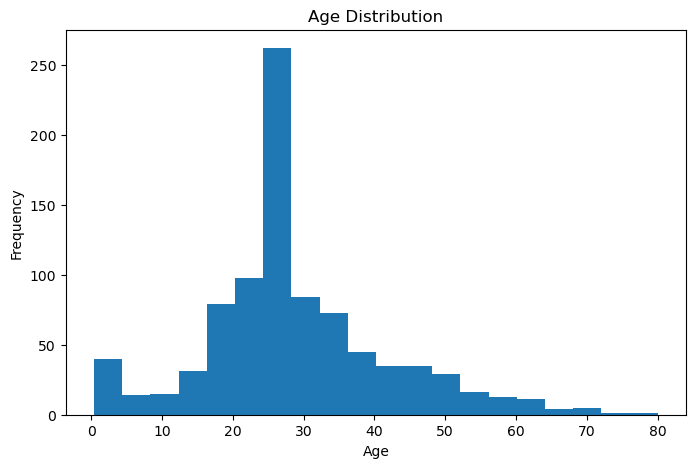

In [42]:
plt.figure(figsize=(8,5))
plt.hist(df['Age'], bins=20)
plt.xlabel("Age")
plt.ylabel("Frequency")
plt.title("Age Distribution")
plt.show()

## Age Distribution

The histogram shows the distribution of passenger ages.

This helps identify:
- skewness
- outliers
- age concentration

Understanding distribution is important before modeling.

Step 16: Survival Rate Calculation

In [43]:
survival_rate = df['Survived'].value_counts(normalize=True) * 100
print(survival_rate)

Survived
0    61.616162
1    38.383838
Name: proportion, dtype: float64


## Survival Distribution

The survival distribution shows the percentage of:
- passengers who survived
- passengers who did not survive

This helps understand class balance in the dataset.

Step 17: Separate Features and Target

In [44]:
target_col = 'Survived'
identifier_cols = ['PassengerId', 'Name', 'Ticket']
X = df.drop(columns=identifier_cols + [target_col])
y = df[target_col]

print("Features Shape:", X.shape)
print("Target Shape:", y.shape)

Features Shape: (891, 7)
Target Shape: (891,)


## Feature and Target Separation

The dataset was divided into:
- X = input features
- y = target variable

Identifier columns were removed because they do not help in prediction.

Step 14: Save Cleaned Dataset

In [45]:
df.to_csv("titanic_cleaned.csv", index=False)

print("Cleaned dataset saved successfully.")

Cleaned dataset saved successfully.


# Final Summary

In this lab:
- The Titanic dataset was loaded successfully
- Missing values were handled
- Cabin column was removed
- Duplicate rows were checked and removed
- Categorical values were standardized
- Features and target variables were separated
- Cleaned dataset was saved successfully

The cleaned data is now ready for:
- Exploratory Data Analysis (EDA)
- Machine Learning
- Classification models